In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "Collected_and_generated_municipal_wastes";',
    engine
)
df

,Id,Year,Type,Total,Vardar,East,Southwest,Southeast,Pelagonia,Polog,Northeast,Skopje
0,1,2008,Collected municipal waste,531281.0,54944.0,49969.0,102271.0,26281.0,49743.0,56902.0,38869.0,152301.0
1,2,2008,Generated municipal waste,713564.0,66457.0,63681.0,156813.0,42260.0,63290.0,96686.0,49820.0,174557.0
2,3,2009,Collected municipal waste,552230.0,58716.0,62497.0,77372.0,30040.0,67758.0,61412.0,49907.0,144529.0
3,4,2009,Generated municipal waste,725976.0,70271.0,79069.0,107669.0,50128.0,82882.0,97967.0,64352.0,173638.0
4,5,2010,Collected municipal waste,545763.0,61312.0,60066.0,66538.0,34404.0,71499.0,64596.0,47087.0,140262.0
5,6,2010,Generated municipal waste,721507.0,73776.0,72223.0,106315.0,54349.0,85104.0,112879.0,56199.0,160661.0
6,7,2011,Collected municipal waste,543954.0,64921.0,69588.0,47432.0,39674.0,65066.0,62388.0,47080.0,147804.0
7,8,2011,Generated municipal waste,735250.0,77935.0,81251.0,87820.0,91364.0,77010.0,90567.0,57467.0,171836.0
8,9,2012,Collected municipal waste,555760.0,61957.0,70485.0,49488.0,45474.0,72176.0,59096.0,52492.0,144593.0
9,10,2012,Generated municipal waste,786909.0,118780.0,82849.0,86960.0,68146.0,85360.0,104289.0,72121.0,168404.0


In [3]:
df = df.drop(columns=['Id'])

df_collected = df[df['Type'] == 'Collected municipal waste'].reset_index(drop=True)
df_generated = df[df['Type'] == 'Generated municipal waste'].reset_index(drop=True)

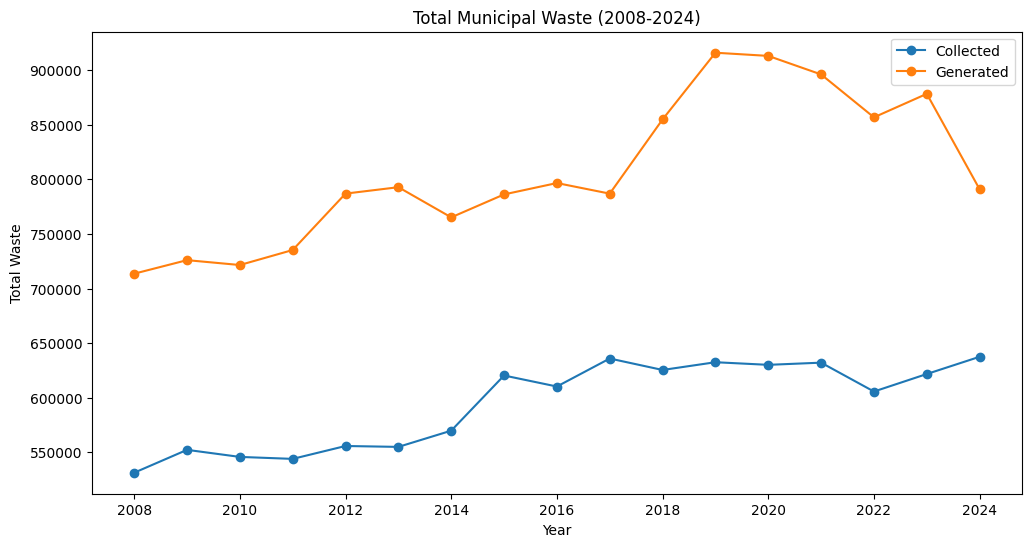

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_collected['Year'], df_collected['Total'], label='Collected', marker='o')
plt.plot(df_generated['Year'], df_generated['Total'], label='Generated', marker='o')
plt.xlabel("Year")
plt.ylabel("Total Waste")
plt.title("Total Municipal Waste (2008-2024)")
plt.legend()
plt.show()

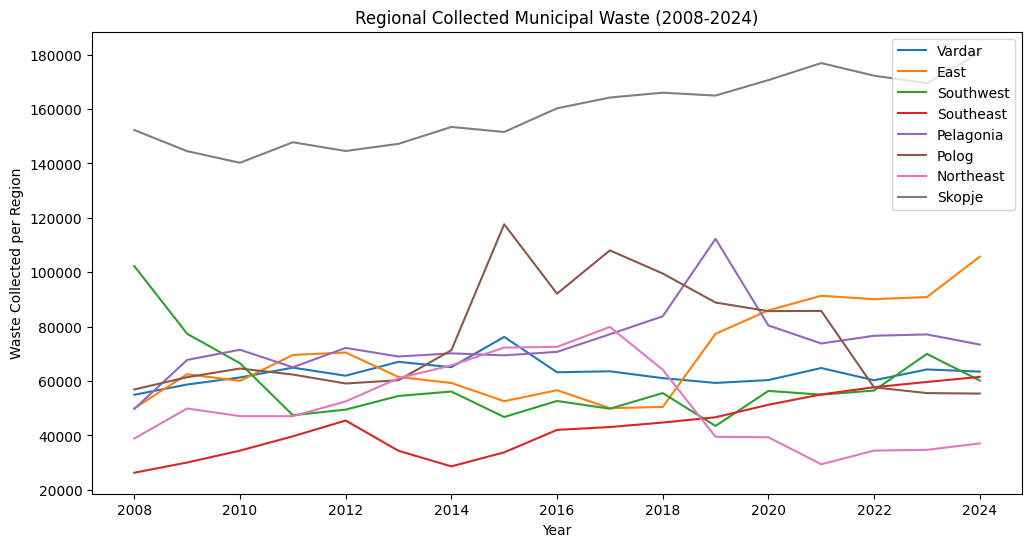

In [5]:
regions = ['Vardar','East','Southwest','Southeast','Pelagonia','Polog','Northeast','Skopje']

plt.figure(figsize=(12,6))
for region in regions:
    plt.plot(df_collected['Year'], df_collected[region], label=region)
plt.xlabel("Year")
plt.ylabel("Waste Collected per Region")
plt.title("Regional Collected Municipal Waste (2008-2024)")
plt.legend()
plt.show()

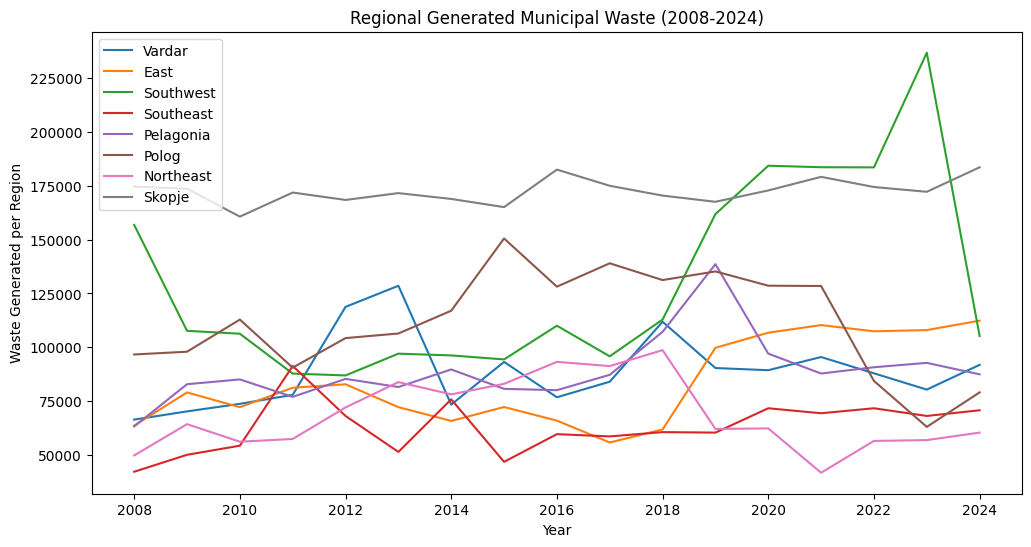

In [6]:
plt.figure(figsize=(12,6))
for region in regions:
    plt.plot(df_generated['Year'], df_generated[region], label=region)
plt.xlabel("Year")
plt.ylabel("Waste Generated per Region")
plt.title("Regional Generated Municipal Waste (2008-2024)")
plt.legend()
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression

X_collected = df_collected[['Year']]
y_collected = df_collected['Total']

lr_collected = LinearRegression()
lr_collected.fit(X_collected, y_collected)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
future_years = pd.DataFrame({'Year':[2025,2026]})
pred_total_collected = lr_collected.predict(future_years)
print("Predicted Total Collected Waste (2025-2026):", pred_total_collected)

Predicted Total Collected Waste (2025-2026): [656005.91176471 662849.78431373]


In [9]:
X_generated = df_generated[['Year']]
y_generated = df_generated['Total']

lr_generated = LinearRegression()
lr_generated.fit(X_generated, y_generated)

pred_total_generated = lr_generated.predict(future_years)
print("Predicted Total Generated Waste (2025-2026):", pred_total_generated)

Predicted Total Generated Waste (2025-2026): [902914.51470588 913587.12745098]


In [10]:
import joblib
from pathlib import Path
import json

BASE_MODEL_DIR = Path("models/collected_generated_total")
BASE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(lr_collected, BASE_MODEL_DIR / "collected_total_linear.pkl")
joblib.dump(lr_generated, BASE_MODEL_DIR / "generated_total_linear.pkl")

metadata_total = {
    "dataset": "Collected_and_generated_municipal_wastes",
    "model_type": "LinearRegression",
    "target": "Total",
    "features": ["Year"],
    "trained_until_year": int(df["Year"].max()),
    "models": {
        "collected": "collected_total_linear.pkl",
        "generated": "generated_total_linear.pkl"
    }
}

with open(BASE_MODEL_DIR / "metadata.json", "w") as f:
    json.dump(metadata_total, f, indent=2)


In [11]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

future_years = pd.DataFrame({'Year':[2025, 2026, 2027, 2028]})

region_forecasts_collected = {}
for region in regions:
    X = df_collected[['Year']]
    y = df_collected[region]
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    region_forecasts_collected[region] = model.predict(future_years)

df_forecast_collected = pd.DataFrame(region_forecasts_collected, index=[2025, 2026, 2027, 2028])
print("Collected Waste Forecasts:")
print(df_forecast_collected)

print('\n\n')

region_forecasts_generated = {}
for region in regions:
    X = df_generated[['Year']]
    y = df_generated[region]
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    region_forecasts_generated[region] = model.predict(future_years)

df_forecast_generated = pd.DataFrame(region_forecasts_generated, index=[2025, 2026, 2027, 2028])
print("Generated Waste Forecasts:")
print(df_forecast_generated)

Collected Waste Forecasts:
        Vardar      East  Southwest  Southeast  Pelagonia    Polog  Northeast  \
2025  63578.77  99689.55   62232.89   60212.38    74710.4  58259.1   35831.86   
2026  63578.77  99689.55   62232.89   60212.38    74710.4  58259.1   35831.86   
2027  63578.77  99689.55   62232.89   60212.38    74710.4  58259.1   35831.86   
2028  63578.77  99689.55   62232.89   60212.38    74710.4  58259.1   35831.86   

         Skopje  
2025  176895.36  
2026  176895.36  
2027  176895.36  
2028  176895.36  



Generated Waste Forecasts:
        Vardar       East  Southwest  Southeast  Pelagonia     Polog  \
2025  88819.45  110748.53   150965.1   70034.53   89256.53  79428.06   
2026  88819.45  110748.53   150965.1   70034.53   89256.53  79428.06   
2027  88819.45  110748.53   150965.1   70034.53   89256.53  79428.06   
2028  88819.45  110748.53   150965.1   70034.53   89256.53  79428.06   

      Northeast     Skopje  
2025    58071.7  179593.52  
2026    58071.7  179593.52  

In [12]:
from sklearn.ensemble import RandomForestRegressor

MODEL_DIR_COLLECTED = Path("models/collected_regions_random_forest")
MODEL_DIR_COLLECTED.mkdir(parents=True, exist_ok=True)

region_models_collected = {}

for region in regions:
    X = df_collected[['Year']]
    y = df_collected[region]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)

    joblib.dump(model, MODEL_DIR_COLLECTED / f"{region}.pkl")
    region_models_collected[region] = model

metadata_collected_regions = {
    "dataset": "Collected_and_generated_municipal_wastes",
    "model_type": "RandomForestRegressor",
    "target_type": "regional",
    "waste_type": "collected",
    "features": ["Year"],
    "regions": regions,
    "trained_until_year": int(df_collected["Year"].max())
}

with open(MODEL_DIR_COLLECTED / "metadata.json", "w") as f:
    json.dump(metadata_collected_regions, f, indent=2)


In [13]:
MODEL_DIR_GENERATED = Path("models/generated_regions_random_forest")
MODEL_DIR_GENERATED.mkdir(parents=True, exist_ok=True)

region_models_generated = {}

for region in regions:
    X = df_generated[['Year']]
    y = df_generated[region]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)

    joblib.dump(model, MODEL_DIR_GENERATED / f"{region}.pkl")
    region_models_generated[region] = model

metadata_generated_regions = {
    "dataset": "Collected_and_generated_municipal_wastes",
    "model_type": "RandomForestRegressor",
    "target_type": "regional",
    "waste_type": "generated",
    "features": ["Year"],
    "regions": regions,
    "trained_until_year": int(df_generated["Year"].max())
}

with open(MODEL_DIR_GENERATED / "metadata.json", "w") as f:
    json.dump(metadata_generated_regions, f, indent=2)
